# Kuramoto Model

Many natural systems contain a large number of interacting oscillators (e.g., Neurons in the brain, flashing fireflies, power grid generators). A remarkable phenomenon that one can observe in such systems is synchronization, where individual oscillators with different natural frequencies come together to oscillate with a common phase. The Kuramoto Model (proposed by Yoshiki Kuramoto in 1975) is a theoretical model that can be used to study synchronization in systems of coupled oscillators.

The goal of the module is to simulate the all-to-all Kuramoto model with sine function coupling and study how synchronization develops as the coupling strength increases between oscillators.

###  All-to-all coupled Kuramoto Model, with sine function coupling

##### Importing required libraries and setting up parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 100 # Number of oscillators
K = 1.5 # Coupling strength
T = 500.0
dt = 0.01 
steps = int(T / dt) 

In [3]:
# Oscillator properties
omega = np.random.normal(0, 1, N) # Choosing natural frequencies from normal distribution
theta = np.random.uniform(0, 2 * np.pi, N) # Initial phases


In [4]:
r_values = [] # To store the order parameter values over time

##### Simulation loop and plots

In [5]:
for t in range(steps):
    phase_diff = theta[:, None] - theta # Compute phase differences
    coupling = np.sum(np.sin(-phase_diff), axis=1) # Coupling term
    dtheta = omega + (K/N) * coupling # Update phases
    theta += dtheta * dt # Euler method for solving the differential equation
    
    z = np.mean(np.exp(1j * theta))
    r = np.abs(z)
    r_values.append(r)

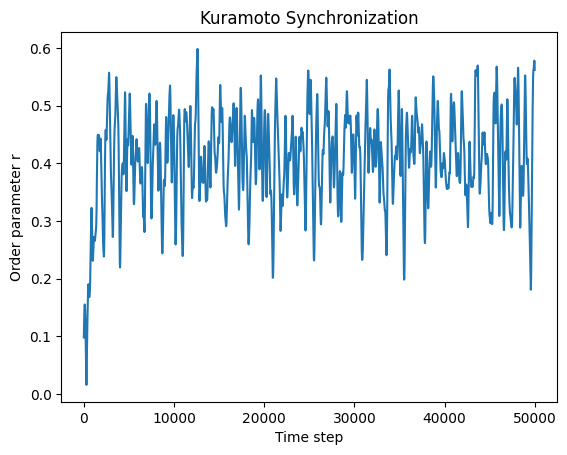

In [6]:
plt.plot(r_values)
plt.xlabel("Time step")
plt.ylabel("Order parameter r")
plt.title("Kuramoto Synchronization")
plt.savefig("Kuramoto_Synchronization_Time.png")
plt.show()

### Synchronization transition obtained through the complex Order parameter

##### Running the simulation many times for different 'K'

In [7]:
K_values = np.linspace(0, 10, 60) # Varying coupling strength
r_final = []
for K in K_values:
    theta = np.random.uniform(0, 2 * np.pi, N) # Reset initial phases
    for t in range(steps):
        phase_diff = theta[:, None] - theta
        coupling = np.sum(np.sin(-phase_diff), axis=1)
        dtheta = omega + (K/N) * coupling
        theta += dtheta * dt
    
    z = np.mean(np.exp(1j * theta))
    r_final.append(np.abs(z))

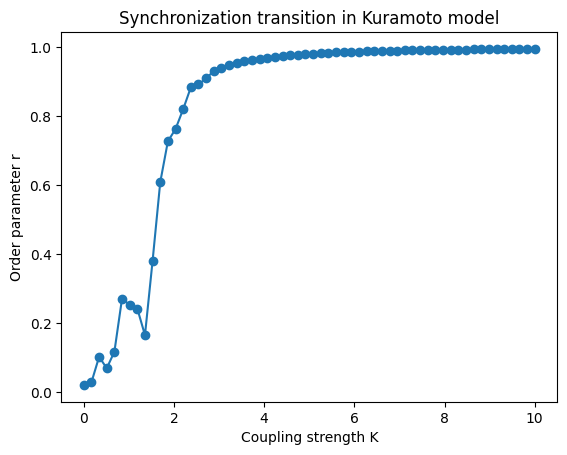

In [8]:
plt.plot(K_values, r_final, 'o-')
plt.xlabel("Coupling strength K")
plt.ylabel("Order parameter r")
plt.title("Synchronization transition in Kuramoto model")
plt.savefig("Kuramoto_Synchronization.png")
plt.show()

### Visualizations

##### Oscillators on a unit circle

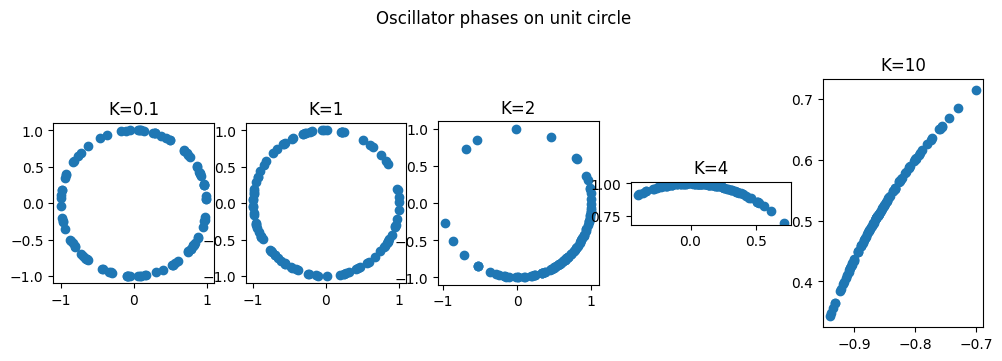

In [9]:
K_values = [0.1, 1, 2, 4, 10]                       # different couplings to visualize
fig,axs = plt.subplots(1,5,figsize=(12,4))

for i,K in enumerate(K_values):               
    theta = np.random.uniform(0,2*np.pi,N)   # initialize phases   
    for t in range(steps):                          
        phase_diff = theta[:,None] - theta        
        coupling = np.sum(np.sin(-phase_diff),axis=1)        
        dtheta = omega + (K/N)*coupling           
        theta = theta + dt*dtheta          

    x = np.cos(theta)                        # x coordinates on unit circle
    y = np.sin(theta)                        # y coordinates on unit circle
    
    axs[i].scatter(x,y)                      # plot oscillator positions    
    axs[i].set_title(f"K={K}")               # subplot title   
    axs[i].set_aspect('equal')               # enforce circular scaling
    
plt.suptitle("Oscillator phases on unit circle")
plt.savefig("Kuramoto_Phase_Distribution.png")   
plt.show()  


##### Phase evolution heat map

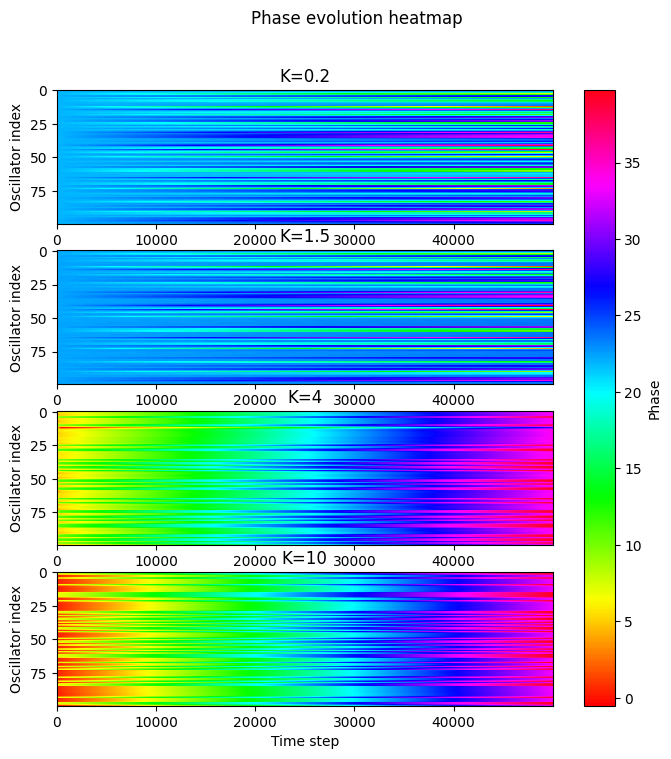

In [10]:
K_values = [0.2,1.5, 4, 10]                       
fig,axs = plt.subplots(4,1,figsize=(8,8))    

for k_index,K in enumerate(K_values):           
    theta = np.random.uniform(0,2*np.pi,N)     
    theta_history = []            # to store phase evolution over time           
    
    for t in range(steps):                          
        theta_history.append(theta.copy())  # store current phases for heatmap     
        phase_diff = theta[:,None] - theta        
        coupling = np.sum(np.sin(-phase_diff),axis=1)   
        dtheta = omega + (K/N)*coupling        
        theta = theta + dt*dtheta          

    theta_history = np.array(theta_history)  
    im = axs[k_index].imshow(theta_history.T,aspect='auto',cmap='hsv')     
    axs[k_index].set_title(f"K={K}")          
    axs[k_index].set_ylabel("Oscillator index")  

axs[-1].set_xlabel("Time step")             
fig.colorbar(im,ax=axs,label="Phase")   
plt.suptitle("Phase evolution heatmap")  
plt.savefig("Kuramoto_Phase_Evolution.png")
plt.show()    

##### Order parameter vs time

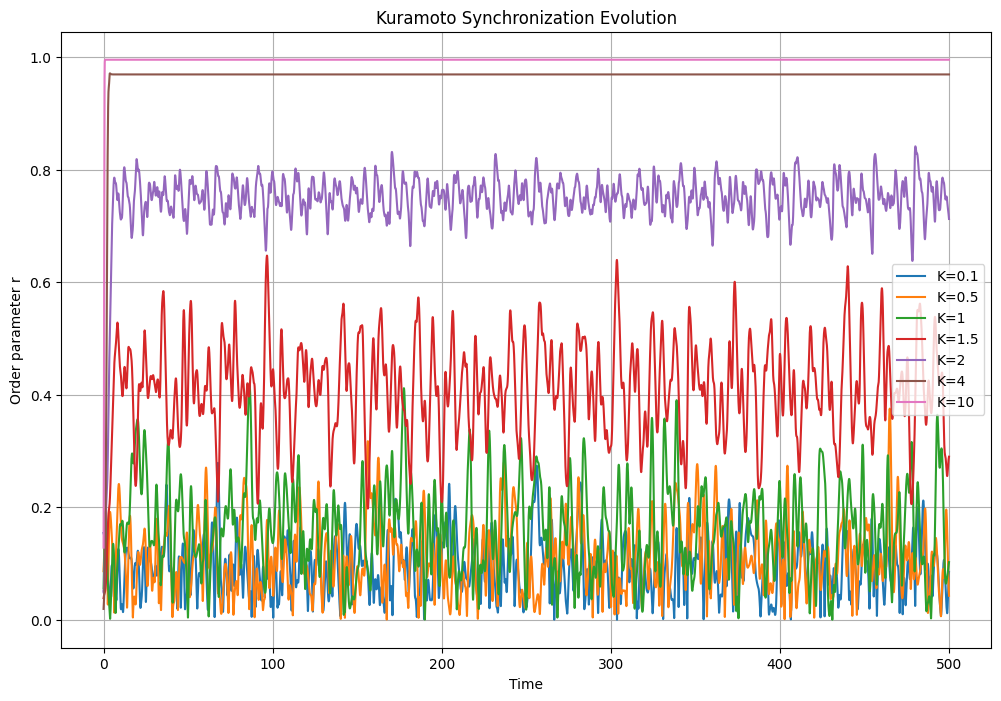

In [11]:
K_values = [0.1, 0.5, 1, 1.5, 2, 4, 10]              
plt.figure(figsize=(12,8))                   

for K in K_values:                          
    theta = np.random.uniform(0,2*np.pi,N)   
    r_values = []                            # store synchronization vs time
    
    for t in range(steps):                 
        phase_diff = theta[:,None] - theta   # compute pairwise phase differences
        coupling = np.sum(np.sin(-phase_diff),axis=1)   # Kuramoto interaction term
        dtheta = omega + (K/N)*coupling    
        theta = theta + dt*dtheta           
        
        z = np.mean(np.exp(1j*theta))        # complex order parameter
        r = np.abs(z)                        # synchronization strength
        r_values.append(r)                   # store r(t)
        
    plt.plot(np.arange(steps)*dt, r_values, label=f"K={K}")   # plot r vs time for this K

plt.xlabel("Time")                          
plt.ylabel("Order parameter r")              
plt.title("Kuramoto Synchronization Evolution")  
plt.legend()                               
plt.grid(True) 
plt.savefig("Kuramoto_Synchronization_Evolution.png")                              
plt.show()                                 